In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [3]:
def running_avg(x, n_windows):
    '''Computes a running average over x'''
    ws = int(len(x)/n_windows)  # size of each window
    return [np.sum(x[i*ws:i*ws+ws])/ws for i in range(int(len(x)/ws))]

In [22]:
out_dir = '/home/gianvito/Desktop/flatland_exp/debug_init_q_bis/exp_0'

cum_reward = np.load(os.path.join(out_dir, "cum_reward.npz"))
arrived_trains = np.load(os.path.join(out_dir, "arrived_trains.npz"))

In [12]:
cum_reward["x"].shape

(10000,)

In [11]:
arrived_trains["x"].shape

(7999,)

In [ ]:
out_dir = '/home/gianvito/Desktop/debug'

cum_reward = np.load(os.path.join(out_dir, "cum_reward.npz"))
arrived_trains = np.load(os.path.join(out_dir, "arrived_trains.npz"))

Text(0.5, 0, 'Episodes')

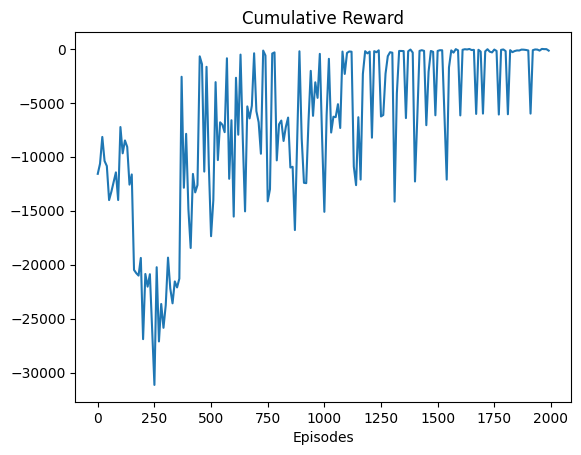

In [23]:
n_windows = 200
num_episodes = 2000
plt.plot(np.arange(0, num_episodes, num_episodes/n_windows), running_avg(cum_reward["x"][:num_episodes], n_windows))
plt.title('Cumulative Reward')
plt.xlabel('Episodes')

In [5]:
at = np.zeros(num_episodes)

at[:num_episodes-1] = arrived_trains["x"]
at[num_episodes-1] = arrived_trains["x"][num_episodes-2]

ValueError: could not broadcast input array from shape (2000,) into shape (1999,)

In [24]:
at = arrived_trains["x"][:num_episodes]

Text(0.5, 0, 'Episodes')

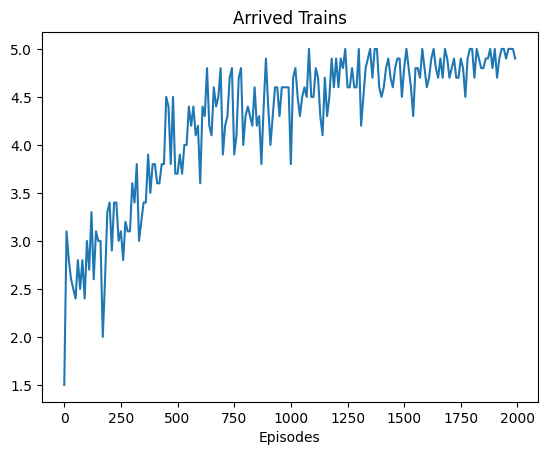

In [25]:
plt.plot(np.arange(0, num_episodes, num_episodes/n_windows), running_avg(at, n_windows))
plt.title('Arrived Trains')
plt.xlabel('Episodes')

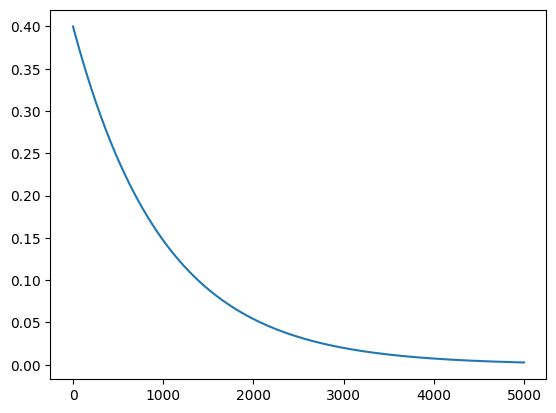

In [26]:
decay = 0.4 * (0.999 ** np.arange(5_000))
plt.plot(decay)

In [3]:
import pickle
filename = os.path.join(out_dir, "checkpoint_4000.pkl")
with open(filename, 'rb') as f:
    q_table = pickle.load(f)

In [4]:
q_table

{(6, 5, 1, 1, 1, -1, -1, -1, -1, 35, 21, -1, -1, 1): [0.0,
  0.0,
  6.704822049952582,
  3.214435800184264,
  -295.3650975321588],
 (6, 6, 1, 1, 1, 35, 21, -1, -1, -1, -1, 1, -1, -1): [5.914935011533848,
  0.0,
  0.0,
  0.0,
  -297.37509119723757],
 (7, 5, 1, 1, 1, 35, 21, -1, -1, -1, -1, 1, -1, -1): [6.464479182505382,
  0.0,
  0.0,
  0.0,
  -295.836546166351],
 (36, 5, 1, 1, 1, -1, -1, -1, -1, 20, 21, -1, -1, 1): [0.0,
  0.0,
  -5.280306423683612,
  -4.705089544154135,
  -306.63056743715214],
 (36, 6, 1, 1, 1, 20, 21, -1, -1, -1, -1, 1, -1, -1): [0.5579227946043489,
  0.0,
  0.0,
  0.0,
  -300.3500615520413],
 (6, 5, 1, 1, 1, -1, -1, -1, -1, 5, 21, -1, -1, 0): [0.0,
  0.0,
  -6.863569489066174,
  -8.955619267823874,
  -308.9749906514296],
 (6, 6, 1, 1, 1, 5, 21, -1, -1, -1, -1, 0, -1, -1): [0.0009382921091552555,
  0.0,
  0.0,
  0.0,
  -300.9828572127678],
 (37, 5, 1, 1, 1, -1, -1, -1, -1, 20, 21, -1, -1, 1): [0.0,
  0.0,
  0.0,
  0.4815864285660646,
  -301.3203438780745],
 (7, 5, 1,

In [7]:
list(q_table.values())

[[0.0, 0.0, 6.704822049952582, 3.214435800184264, -295.3650975321588],
 [5.914935011533848, 0.0, 0.0, 0.0, -297.37509119723757],
 [6.464479182505382, 0.0, 0.0, 0.0, -295.836546166351],
 [0.0, 0.0, -5.280306423683612, -4.705089544154135, -306.63056743715214],
 [0.5579227946043489, 0.0, 0.0, 0.0, -300.3500615520413],
 [0.0, 0.0, -6.863569489066174, -8.955619267823874, -308.9749906514296],
 [0.0009382921091552555, 0.0, 0.0, 0.0, -300.9828572127678],
 [0.0, 0.0, 0.0, 0.4815864285660646, -301.3203438780745],
 [0.0009349681715170502, 0.0, 0.0, 0.0, -301.6092583089278],
 [-1.4975793177086016, 0.19617488705003733, 0.0, 0.0, -301.48190422675754],
 [0.0, -38.8931309246389, -5.26219519252072, 0.0, 6.7016749343565705],
 [0.9175422763864701, 0.0, 0.0, 0.0, -277.4045061770966],
 [0.0, 0.0, -28.86456429650065, -1.6500216902261238, -229.54403040249062],
 [1.0191684987207184, 0.0, 0.0, 0.0, -270.7051824036336],
 [0.0, -4.816417813308725, -7.018865118413548, 0.0, -303.505042740944],
 [0.0, 0.0, 0.0, 0.3

# Error plot

In [3]:
list_dir = [
    '/home/gianvito/Desktop/flatland_exp/5_agents_with_init/exp_0/seed_0',
    '/home/gianvito/Desktop/flatland_exp/5_agents_with_init/exp_0/seed_1',
    '/home/gianvito/Desktop/flatland_exp/5_agents_with_init/exp_0/seed_2',
    '/home/gianvito/Desktop/flatland_exp/5_agents_with_init/exp_0/seed_3',
    '/home/gianvito/Desktop/flatland_exp/5_agents_with_init/exp_0/seed_4',
]

In [4]:
num_episodes = 2_000
n_windows = 500

aggr_rew = np.zeros((len(list_dir), num_episodes))

for i, out_dir in enumerate(list_dir):
    cum_reward = np.load(os.path.join(out_dir, "cum_reward.npz"))
    aggr_rew[i, :] = cum_reward["x"][:num_episodes]

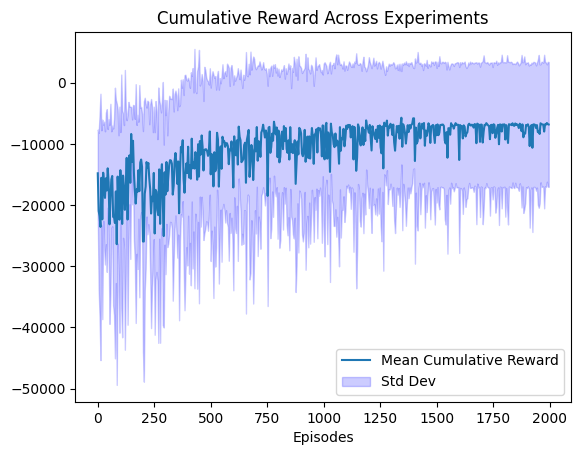

In [5]:
fig, ax = plt.subplots()

ax.plot(np.arange(0, num_episodes, num_episodes/n_windows),
        running_avg(np.mean(aggr_rew, axis=0), n_windows), label='Mean Cumulative Reward')
ax.fill_between(np.arange(0, num_episodes, num_episodes/n_windows),
                running_avg(np.mean(aggr_rew, axis=0) - np.std(aggr_rew, axis=0), n_windows),
                running_avg(np.mean(aggr_rew, axis=0) + np.std(aggr_rew, axis=0), n_windows),
                color='b', alpha=0.2, label='Std Dev')
ax.set_title('Cumulative Reward Across Experiments')
ax.set_xlabel('Episodes')
ax.legend()

In [6]:
aggr_trains = np.zeros((len(list_dir), num_episodes))
for i, out_dir in enumerate(list_dir):
    arrived_trains = np.load(os.path.join(out_dir, "arrived_trains.npz"))
    aggr_trains[i, :] = arrived_trains["x"][:num_episodes]

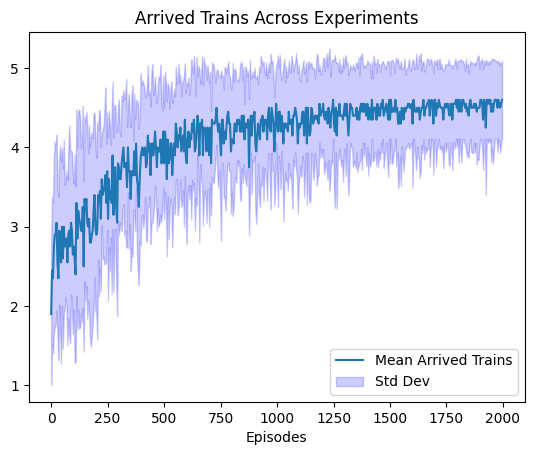

In [7]:
fig, ax = plt.subplots()

ax.plot(np.arange(0, num_episodes, num_episodes/n_windows),
        running_avg(np.mean(aggr_trains, axis=0), n_windows), label='Mean Arrived Trains')
ax.fill_between(np.arange(0, num_episodes, num_episodes/n_windows),
                running_avg(np.mean(aggr_trains, axis=0) - np.std(aggr_trains, axis=0), n_windows),
                running_avg(np.mean(aggr_trains, axis=0) + np.std(aggr_trains, axis=0), n_windows),
                color='b', alpha=0.2, label='Std Dev')
ax.set_title('Arrived Trains Across Experiments')
ax.set_xlabel('Episodes')
ax.legend()


In [4]:
path = '/home/gianvito/Desktop/flatland_exp/5_agents_with_init/exp_0/seed_0/trains_at_dest.npz'
trains_at_dest = np.load(path)
trains_at_dest["x"]

array([0, 1, 2, 3, 4])